In [39]:
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import array_to_latex, plot_histogram
from IPython.display import display

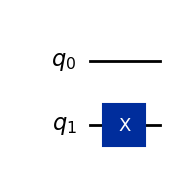

In [40]:
constant_oracle = QuantumCircuit(2)
output = np.random.randint(2)

if output == 1:
    constant_oracle.x(1)

constant_oracle.draw('mpl')

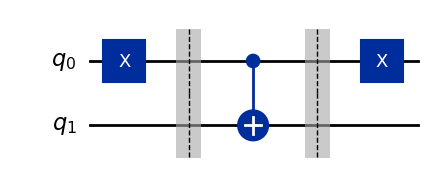

In [41]:
balanced_oracle = QuantumCircuit(2)
balanced_oracle.x(0)
balanced_oracle.barrier()
balanced_oracle.cx(0, 1)
balanced_oracle.barrier()
balanced_oracle.x(0)
balanced_oracle.draw('mpl')

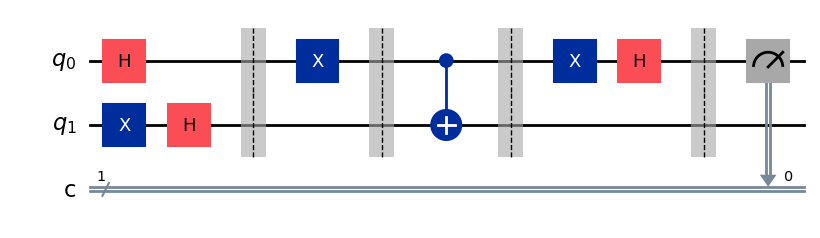

In [82]:
#oracle_fn = constant_oracle

oracle_fn = balanced_oracle


dj_circuit = QuantumCircuit(2, 1)
dj_circuit.h(0)
dj_circuit.x(1)
dj_circuit.h(1)
dj_circuit.barrier()
dj_circuit = dj_circuit.compose(oracle_fn)
dj_circuit.h(0)
dj_circuit.barrier()
dj_circuit.measure(0, 0)
dj_circuit.draw('mpl')


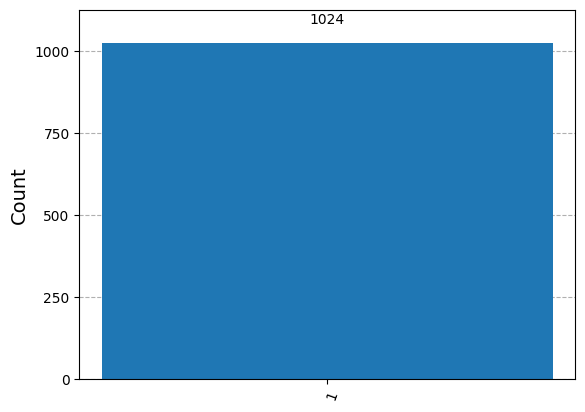

In [81]:
job =  Aer.get_backend('qasm_simulator').run(dj_circuit)
shots = 1024
result = job.result()
answer = result.get_counts()

plot_histogram(answer)

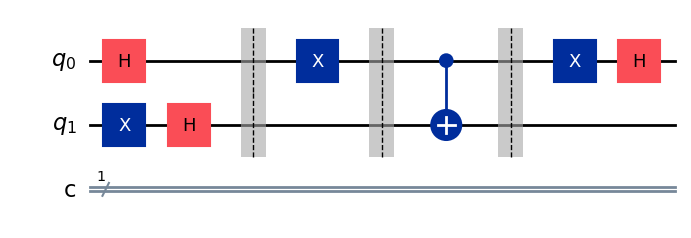

<IPython.core.display.Latex object>

In [74]:
oracle_fn = constant_oracle
#oracle_fn = balanced_oracle


dj_circuit = QuantumCircuit(2, 1)
dj_circuit.h(0)
dj_circuit.x(1)
dj_circuit.h(1)
dj_circuit.barrier()

# Stable oracle

# BAlanced oracle
dj_circuit.x(0)
dj_circuit.barrier()
dj_circuit.cx(0, 1)
dj_circuit.barrier()
dj_circuit.x(0)


dj_circuit.h(0)
# dj_circuit.barrier()
# dj_circuit.measure(0, 0)
display(dj_circuit.draw('mpl'))

unitary = Aer.get_backend('unitary_simulator').run(dj_circuit).result().get_unitary()
statevector = Aer.get_backend('statevector_simulator').run(dj_circuit).result().get_statevector()
#counts = Aer.get_backend('statevector_simulator').run(dj_circuit).result().get_counts()
#display(qiskit.visualization.plot_histogram(counts))
display(array_to_latex(unitary, prefix="\\text{Unitary Matrix} = "))
#qiskit.visualization.plot_bloch_multivector(statevector)




<IPython.core.display.Latex object>

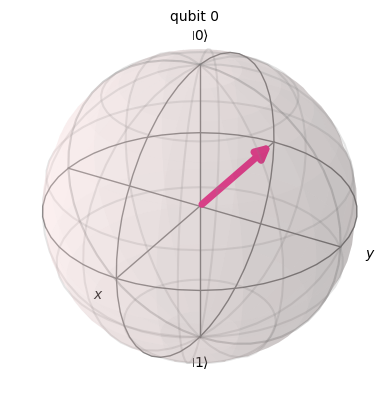

In [60]:
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
#qc.x(0)


unitary = Aer.get_backend('unitary_simulator').run(qc).result().get_unitary()
statevector = Aer.get_backend('statevector_simulator').run(qc).result().get_statevector()
#counts = Aer.get_backend('statevector_simulator').run(dj_circuit).result().get_counts()
#display(qiskit.visualization.plot_histogram(counts))
display(array_to_latex(unitary, prefix="\\text{Unitary Matrix} = "))
qiskit.visualization.plot_bloch_multivector(statevector)
